In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('datos_curados.csv')
df

,Localidad,Cultivar,Repetición,α Tocopherol,γ Tocopherol,δ Tocopherol,α+γ+δ Tocopherol,Palmitic Acid,Palmitoleic Acid,Stearic Acid,...,inicio de floración IF,Madurez fisiologica MF,Dur S-IF,Dur S-MF,Dur IF-MF,Tmx IF-MF,Tmed IF-MF,T mn IF-MF,pp IF-MF,etp IF- MF
0,Loc_1,cv_1,1,502.64,826.36,6.18,1335.18,4.26,0.20,2.04,...,2012-10-04,2012-11-26,157,211,54,29.9,23.05,17.1,214.0,222.8
1,Loc_1,cv_1,2,511.20,788.10,7.36,1306.66,4.24,0.20,1.96,...,2012-10-04,2012-11-26,157,211,54,29.9,23.05,17.1,214.0,222.8
2,Loc_1,cv_2,1,317.95,726.27,0.00,1044.22,3.96,0.17,1.89,...,2012-09-29,2012-11-25,152,210,58,28.7,21.70,15.0,214.9,232.1
3,Loc_1,cv_2,2,356.28,796.46,7.22,1159.96,4.45,0.19,2.21,...,2012-09-29,2012-11-25,152,210,58,28.7,21.70,15.0,214.9,232.1
4,Loc_1,cv_3,1,405.68,745.75,3.79,1155.22,4.17,0.17,1.95,...,2012-09-23,2012-11-17,146,202,56,28.7,21.70,15.0,185.3,225.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Loc_4,cv_11,2,301.55,529.71,10.12,841.38,3.90,0.13,1.95,...,2012-09-18,2012-11-18,126,187,62,21.3,15.00,8.7,0.0,196.0
100,Loc_4,cv_12,1,307.06,558.40,1.97,867.43,4.01,0.20,2.06,...,2012-09-13,2012-11-15,121,184,64,21.3,14.90,8.5,0.0,196.9
101,Loc_4,cv_12,2,321.44,631.59,4.95,957.98,3.96,0.16,1.59,...,2012-09-13,2012-11-15,121,184,64,21.3,14.90,8.5,0.0,196.9
102,Loc_4,cv_13,1,284.28,621.01,7.25,912.54,3.94,0.18,2.06,...,2012-09-12,2012-11-15,120,184,65,21.3,14.90,8.4,0.0,194.3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Localidad               104 non-null    object 
 1   Cultivar                104 non-null    object 
 2   Repetición              104 non-null    int64  
 3   α Tocopherol            104 non-null    float64
 4   γ Tocopherol            104 non-null    float64
 5   δ Tocopherol            104 non-null    float64
 6   α+γ+δ Tocopherol        104 non-null    float64
 7   Palmitic Acid           104 non-null    float64
 8   Palmitoleic Acid        104 non-null    float64
 9   Stearic Acid            104 non-null    float64
 10  Oleic Acid              104 non-null    float64
 11  Linoleic Acid           104 non-null    float64
 12  Linolenic Acid          104 non-null    float64
 13  Arachidic Acid          104 non-null    float64
 14  Ecosenoic Acid          104 non-null    fl

4) ¿Cuál de los factores (cultivar o ambiente) aporta mayor variación al contenido de ácidos grasos del grano?

In [7]:
df.columns

Index(['Localidad', 'Cultivar', 'Repetición', 'α Tocopherol', 'γ Tocopherol',
       'δ Tocopherol', 'α+γ+δ Tocopherol', 'Palmitic Acid', 'Palmitoleic Acid',
       'Stearic Acid', 'Oleic Acid', 'Linoleic Acid', 'Linolenic Acid',
       'Arachidic Acid', 'Ecosenoic Acid', 'OSI', 'Oil content', 'Código',
       'IV', 'Fecha de siembra S', 'inicio de floración IF',
       'Madurez fisiologica MF', 'Dur S-IF', 'Dur S-MF', 'Dur IF-MF',
       'Tmx IF-MF', 'Tmed IF-MF', 'T mn IF-MF', 'pp IF-MF', 'etp IF- MF'],
      dtype='object')

In [26]:
df_4 = df.copy()[['Localidad', 'Cultivar', 'Palmitic Acid', 'Palmitoleic Acid',
                 'Stearic Acid', 'Oleic Acid', 'Linoleic Acid', 'Linolenic Acid',
                 'Arachidic Acid', 'Ecosenoic Acid']]
df_4[['Localidad', 'Cultivar', 'Palmitic Acid']]

,Localidad,Cultivar,Palmitic Acid
0,Loc_1,cv_1,4.26
1,Loc_1,cv_1,4.24
2,Loc_1,cv_2,3.96
3,Loc_1,cv_2,4.45
4,Loc_1,cv_3,4.17
...,...,...,...
99,Loc_4,cv_11,3.90
100,Loc_4,cv_12,4.01
101,Loc_4,cv_12,3.96
102,Loc_4,cv_13,3.94


In [34]:
# Pivotear el DataFrame utilizando pivot_table y la función de agregación (mean)
pivot_df = df_4.pivot_table(index='Localidad', columns='Cultivar', values='Palmitic Acid', aggfunc=lambda x: list(x))
# Mostrar el DataFrame pivotado
pivot_df

Cultivar,cv_1,cv_10,cv_11,cv_12,cv_13,cv_2,cv_3,cv_4,cv_5,cv_6,cv_7,cv_8,cv_9
Localidad,,,,,,,,,,,,,
Loc_1,"[4.26, 4.24]","[4.07, 3.96]","[3.97, 4.04]","[3.89, 3.94]","[3.93, 3.95]","[3.96, 4.45]","[4.17, 4.42]","[3.99, 4.15]","[4.02, 3.85]","[4.09, 4.19]","[3.95, 3.95]","[3.8, 3.79]","[3.99, 4.21]"
Loc_2,"[4.1, 4.06]","[3.86, 4.16]","[3.92, 3.88]","[4.18, 3.77]","[4.17, 4.16]","[3.9, 3.95]","[3.93, 4.18]","[4.03, 4.05]","[3.77, 3.77]","[4.31, 4.27]","[4.15, 4.22]","[3.78, 3.87]","[3.89, 3.89]"
Loc_3,"[3.65, 3.64]","[3.87, 3.83]","[3.91, 3.97]","[3.89, 4.01]","[3.96, 3.86]","[4.1, 3.61]","[4.08, 3.76]","[3.56, 4.06]","[3.64, 3.7]","[3.79, 4.03]","[3.9, 3.89]","[3.74, 3.8]","[3.79, 3.79]"
Loc_4,"[4.33, 3.93]","[4.0, 3.61]","[4.61, 3.9]","[4.01, 3.96]","[3.94, 3.65]","[4.15, 3.81]","[4.0, 4.06]","[4.28, 4.31]","[4.61, 4.37]","[4.02, 4.02]","[3.9, 3.81]","[4.26, 4.46]","[3.89, 3.97]"


In [36]:
df_4.columns= df_4.columns.str.replace(' ', '_')

In [38]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Realizar el ANOVA de dos factores
model = ols('Palmitic_Acid ~ C(Localidad) + C(Cultivar) + C(Localidad):C(Cultivar)', data=df_4).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Imprimir la tabla de ANOVA
print(anova_table)

# Analizar la significancia de Localidad, Cultivar y la interacción
alpha = 0.05
print("\nResultados del ANOVA:")
if anova_table['PR(>F)']['C(Localidad)'] < alpha:
    print("El efecto de 'Localidad' es significativo.")
else:
    print("El efecto de 'Localidad' no es significativo.")

if anova_table['PR(>F)']['C(Cultivar)'] < alpha:
    print("El efecto de 'Cultivar' es significativo.")
else:
    print("El efecto de 'Cultivar' no es significativo.")

if anova_table['PR(>F)']['C(Localidad):C(Cultivar)'] < alpha:
    print("La interacción entre 'Localidad' y 'Cultivar' es significativa.")
else:
    print("No hay evidencia de interacción significativa entre 'Localidad' y 'Cultivar'.")


                            sum_sq    df          F    PR(>F)
C(Localidad)              0.854804   3.0  11.400015  0.000007
C(Cultivar)               0.310513  12.0   1.035284  0.432108
C(Localidad):C(Cultivar)  2.132071  36.0   2.369515  0.002209
Residual                  1.299700  52.0        NaN       NaN

Resultados del ANOVA:
El efecto de 'Localidad' es significativo.
El efecto de 'Cultivar' no es significativo.
La interacción entre 'Localidad' y 'Cultivar' es significativa.


In [40]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Carga tu dataframe
df_prueba = df_4.copy()[['Palmitic_Acid','Cultivar', 'Localidad']]

# Crea el modelo ANOVA de dos vías
model = ols('Palmitic_Acid ~ Cultivar + Localidad + Cultivar:Localidad', data=df_prueba).fit()

# Realiza el análisis de varianza
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

# Verificar si "Cultivar" tiene un efecto significativo
p_cultivar = anova_table.loc['Cultivar', 'PR(>F)']
if p_cultivar < 0.05:
    print("El factor 'Cultivar' tiene un efecto significativo en la variación.")
else:
    print("El factor 'Cultivar' no tiene un efecto significativo en la variación.")

# Verificar si "Localidad" tiene un efecto significativo
p_localidad = anova_table.loc['Localidad', 'PR(>F)']
if p_localidad < 0.05:
    print("El factor 'Localidad' tiene un efecto significativo en la variación.")
else:
    print("El factor 'Localidad' no tiene un efecto significativo en la variación.")


                      sum_sq    df          F    PR(>F)
Cultivar            0.310513  12.0   1.035284  0.432108
Localidad           0.854804   3.0  11.400015  0.000007
Cultivar:Localidad  2.132071  36.0   2.369515  0.002209
Residual            1.299700  52.0        NaN       NaN
El factor 'Cultivar' no tiene un efecto significativo en la variación.
El factor 'Localidad' tiene un efecto significativo en la variación.


In [42]:
def analyze_factor_effect(anova_table, factor_name):
    p_factor = anova_table.loc[factor_name, 'PR(>F)']
    if p_factor < 0.05:
        return f"El factor '{factor_name}' tiene un efecto significativo en la variación."
    else:
        return f"El factor '{factor_name}' no tiene un efecto significativo en la variación."

def perform_anova(dataframe, response_column, factor_columns):
    df_prueba = dataframe.copy()

    formula = f"{response_column} ~ {' + '.join(factor_columns)} + {' * '.join(factor_columns)}"
    model = ols(formula, data=df_prueba).fit()

    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA para la columna {response_column} : ","\n\n",anova_table,"\n")

    for factor in factor_columns:
        factor_effect = analyze_factor_effect(anova_table, factor)
        print(factor_effect)

    p_interaction = anova_table.loc['Cultivar:Localidad', 'PR(>F)']
    if p_interaction < 0.05:
        print("Hay una interacción significativa entre 'Cultivar' y 'Localidad'.")
    else:
        print("No hay una interacción significativa entre 'Cultivar' y 'Localidad'.")

    print("="*70,'\n')

# Carga tu dataframe
df_prueba = df_4.copy()

# Llama a la función para analizar ANOVA en todas las columnas de factores
response_columns = ['Palmitic_Acid', 'Palmitoleic_Acid', 'Stearic_Acid', 'Oleic_Acid',
                    'Linoleic_Acid', 'Linolenic_Acid','Arachidic_Acid', 'Ecosenoic_Acid']
factor_columns = ['Cultivar', 'Localidad']

for col in response_columns:
    perform_anova(df_prueba, col, factor_columns)


ANOVA para la columna Palmitic_Acid :  

                       sum_sq    df          F    PR(>F)
Cultivar            0.310513  12.0   1.035284  0.432108
Localidad           0.854804   3.0  11.400015  0.000007
Cultivar:Localidad  2.132071  36.0   2.369515  0.002209
Residual            1.299700  52.0        NaN       NaN 

El factor 'Cultivar' no tiene un efecto significativo en la variación.
El factor 'Localidad' tiene un efecto significativo en la variación.
Hay una interacción significativa entre 'Cultivar' y 'Localidad'.

ANOVA para la columna Palmitoleic_Acid :  

                       sum_sq    df         F    PR(>F)
Cultivar            0.027663  12.0  1.971628  0.046454
Localidad           0.012081   3.0  3.444079  0.023196
Cultivar:Localidad  0.050544  36.0  1.200795  0.269316
Residual            0.060800  52.0       NaN       NaN 

El factor 'Cultivar' tiene un efecto significativo en la variación.
El factor 'Localidad' tiene un efecto significativo en la variación.
No hay una

ANOVA para la columna Palmitic_Acid :  

                       sum_sq    df          F    PR(>F)
Cultivar            0.310513  12.0   1.035284  0.432108
Localidad           0.854804   3.0  11.400015  0.000007
Cultivar:Localidad  2.132071  36.0   2.369515  0.002209
Residual            1.299700  52.0        NaN       NaN 

El factor 'Cultivar' no tiene un efecto significativo en la variación.
El factor 'Localidad' tiene un efecto significativo en la variación.
Hay una interacción significativa entre 'Cultivar' y 'Localidad'.


<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])
<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])


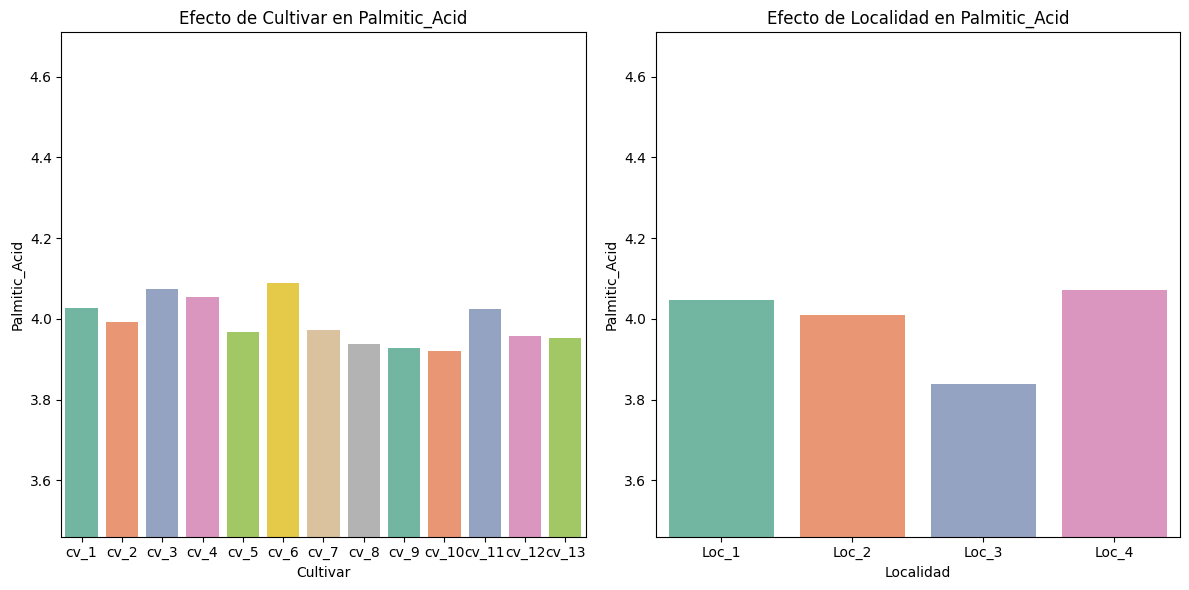

ANOVA para la columna Palmitoleic_Acid :  

                       sum_sq    df         F    PR(>F)
Cultivar            0.027663  12.0  1.971628  0.046454
Localidad           0.012081   3.0  3.444079  0.023196
Cultivar:Localidad  0.050544  36.0  1.200795  0.269316
Residual            0.060800  52.0       NaN       NaN 

El factor 'Cultivar' tiene un efecto significativo en la variación.
El factor 'Localidad' tiene un efecto significativo en la variación.
No hay una interacción significativa entre 'Cultivar' y 'Localidad'.


<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])
<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])


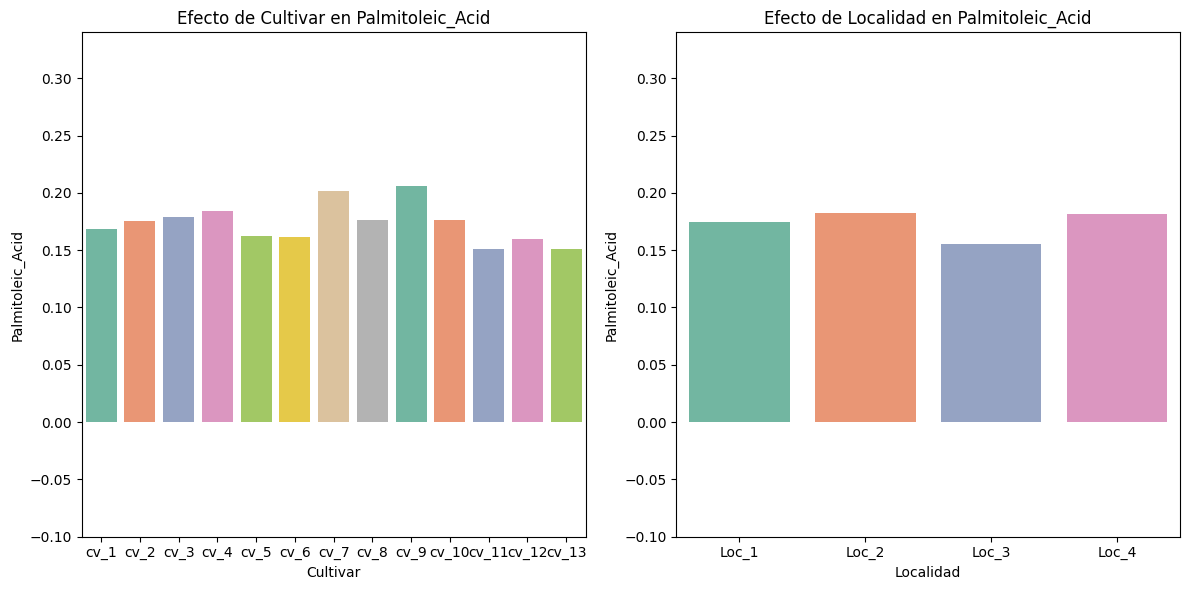

ANOVA para la columna Stearic_Acid :  

                       sum_sq    df         F        PR(>F)
Cultivar            5.825240  12.0  9.326353  2.990405e-09
Localidad           1.446342   3.0  9.262519  5.214428e-05
Cultivar:Localidad  2.925183  36.0  1.561097  6.989204e-02
Residual            2.706600  52.0       NaN           NaN 

El factor 'Cultivar' tiene un efecto significativo en la variación.
El factor 'Localidad' tiene un efecto significativo en la variación.
No hay una interacción significativa entre 'Cultivar' y 'Localidad'.


<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])
<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])


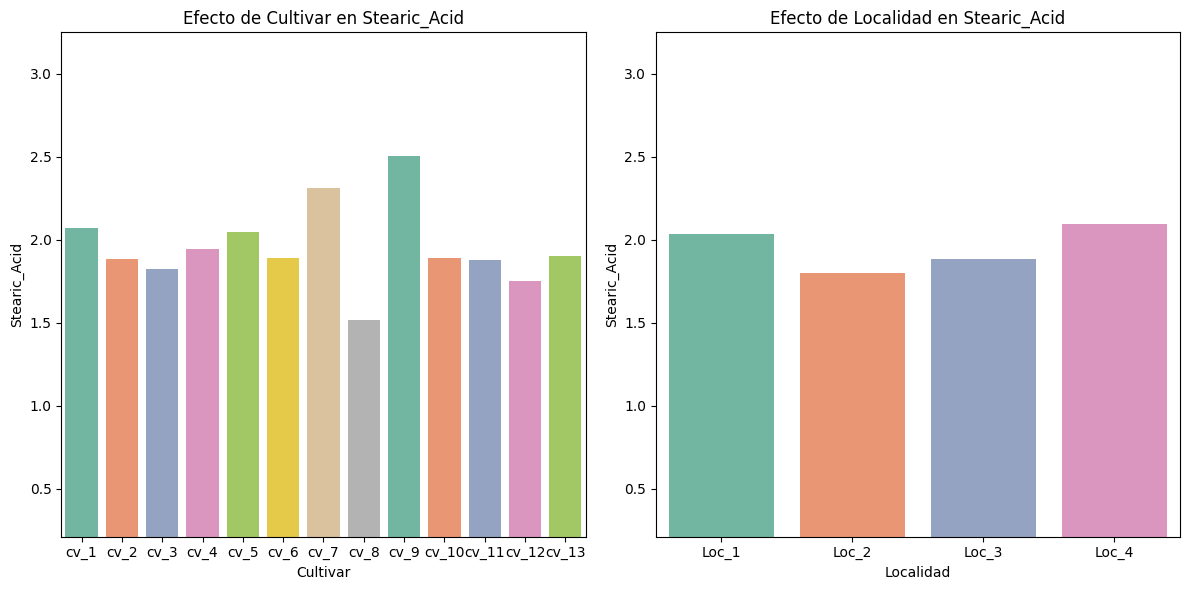

ANOVA para la columna Oleic_Acid :  

                         sum_sq    df          F    PR(>F)
Cultivar            146.119671  12.0   5.051997  0.000017
Localidad            85.449457   3.0  11.817448  0.000005
Cultivar:Localidad  144.082706  36.0   1.660523  0.046496
Residual            125.333650  52.0        NaN       NaN 

El factor 'Cultivar' tiene un efecto significativo en la variación.
El factor 'Localidad' tiene un efecto significativo en la variación.
Hay una interacción significativa entre 'Cultivar' y 'Localidad'.


<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])
<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])


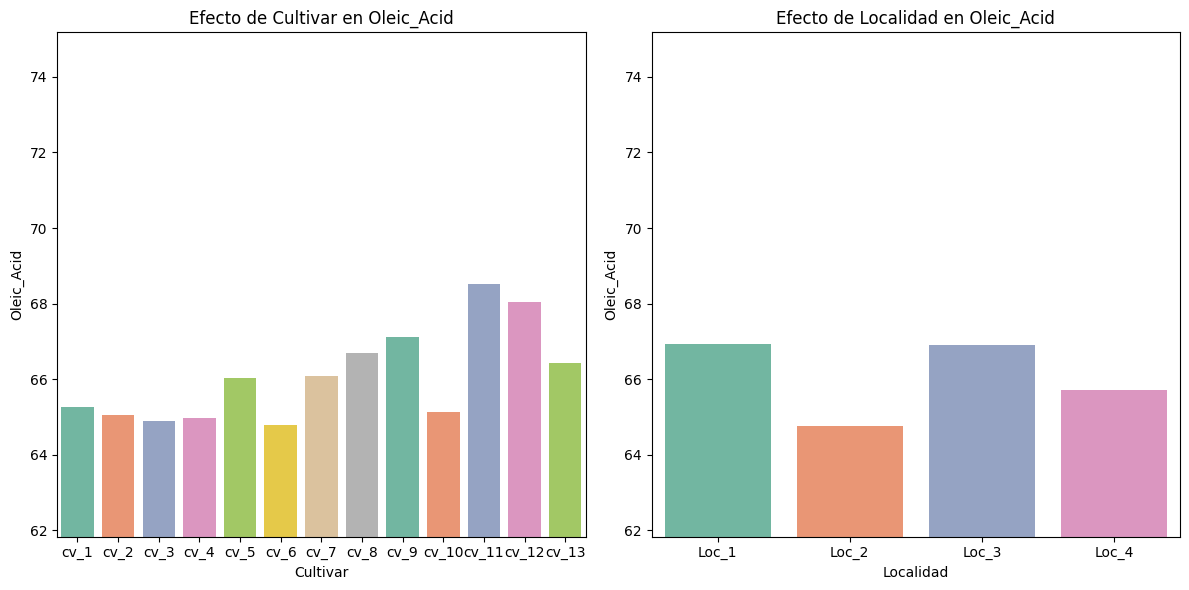

ANOVA para la columna Linoleic_Acid :  

                         sum_sq    df         F        PR(>F)
Cultivar            154.015888  12.0  6.532188  6.315996e-07
Localidad            22.105654   3.0  3.750218  1.632726e-02
Cultivar:Localidad  129.164296  36.0  1.826057  2.315774e-02
Residual            102.171300  52.0       NaN           NaN 

El factor 'Cultivar' tiene un efecto significativo en la variación.
El factor 'Localidad' tiene un efecto significativo en la variación.
Hay una interacción significativa entre 'Cultivar' y 'Localidad'.


<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])
<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])


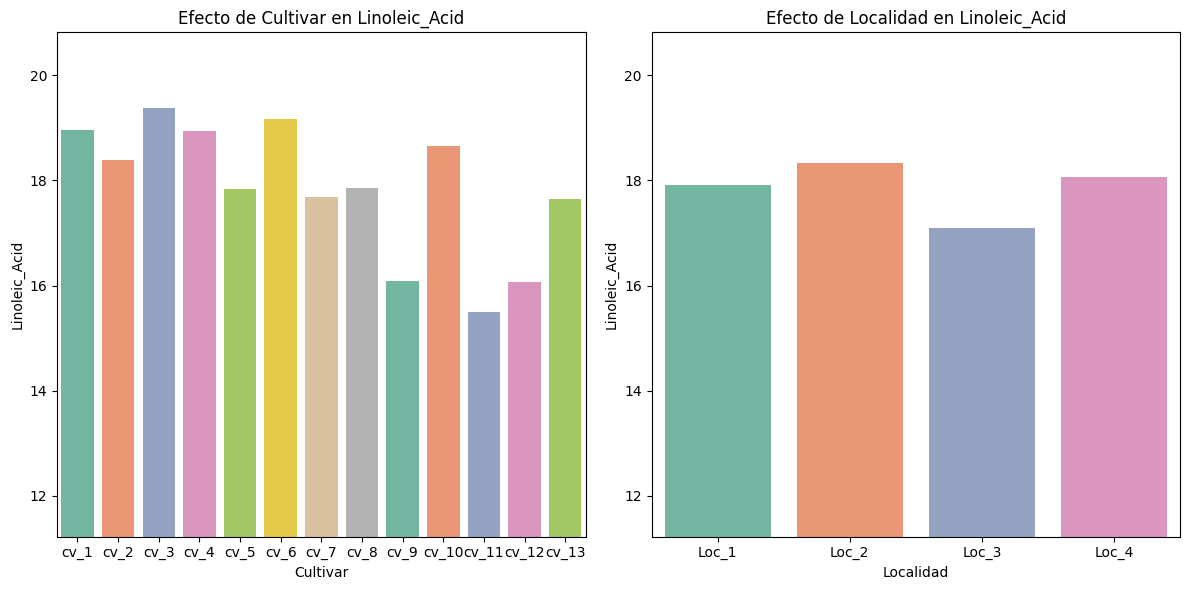

ANOVA para la columna Linolenic_Acid :  

                        sum_sq    df          F        PR(>F)
Cultivar             3.820887  12.0   1.940768  5.037493e-02
Localidad           48.896049   3.0  99.344354  1.591666e-21
Cultivar:Localidad   6.134813  36.0   1.038699  4.435793e-01
Residual             8.531250  52.0        NaN           NaN 

El factor 'Cultivar' no tiene un efecto significativo en la variación.
El factor 'Localidad' tiene un efecto significativo en la variación.
No hay una interacción significativa entre 'Cultivar' y 'Localidad'.


<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])
<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])


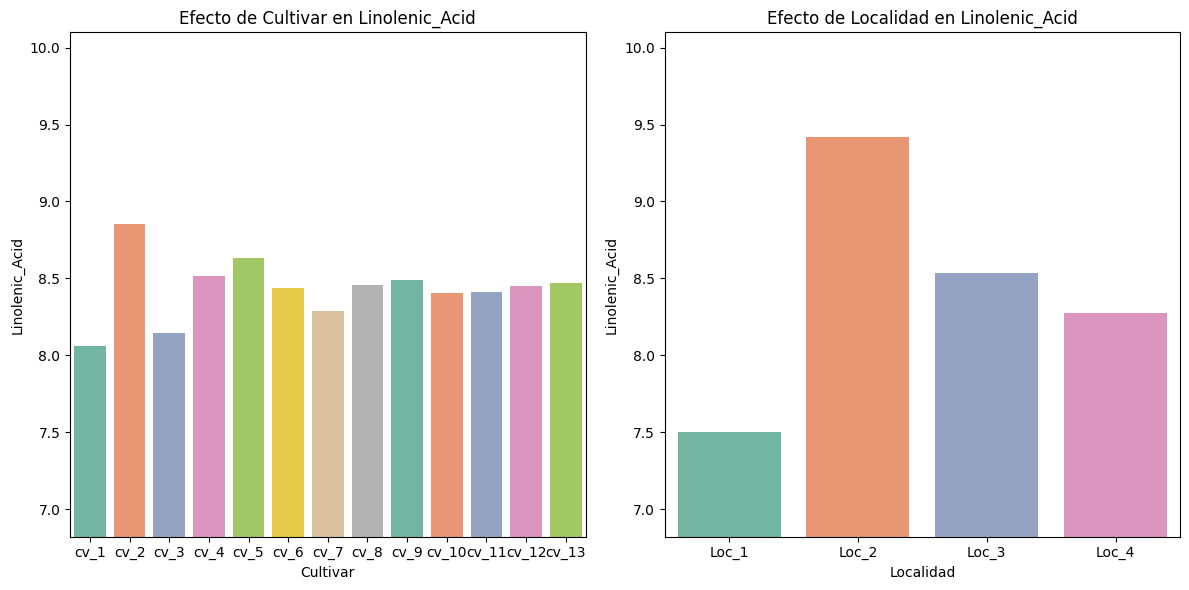

ANOVA para la columna Arachidic_Acid :  

                       sum_sq    df         F    PR(>F)
Cultivar            0.225779  12.0  0.711882  0.732945
Localidad           0.036980   3.0  0.466390  0.706984
Cultivar:Localidad  1.458983  36.0  1.533394  0.078143
Residual            1.374350  52.0       NaN       NaN 

El factor 'Cultivar' no tiene un efecto significativo en la variación.
El factor 'Localidad' no tiene un efecto significativo en la variación.
No hay una interacción significativa entre 'Cultivar' y 'Localidad'.


<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])
<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])


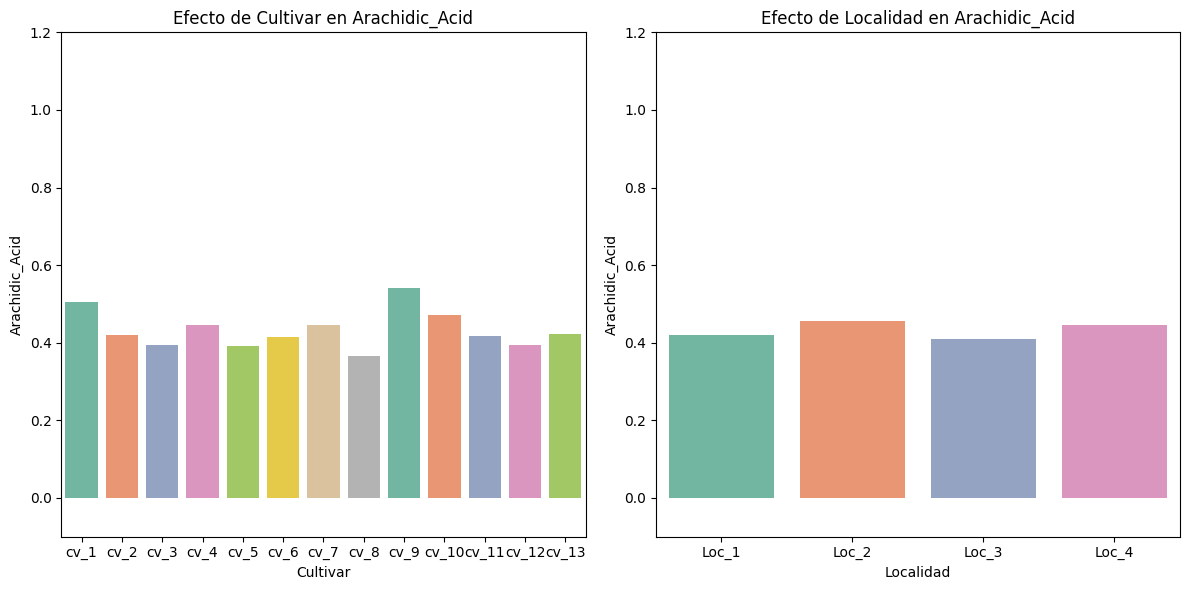

ANOVA para la columna Ecosenoic_Acid :  

                       sum_sq    df         F    PR(>F)
Cultivar            1.063990  12.0  1.395784  0.197982
Localidad           0.293788   3.0  1.541608  0.214751
Cultivar:Localidad  2.063025  36.0  0.902119  0.623339
Residual            3.303250  52.0       NaN       NaN 

El factor 'Cultivar' no tiene un efecto significativo en la variación.
El factor 'Localidad' no tiene un efecto significativo en la variación.
No hay una interacción significativa entre 'Cultivar' y 'Localidad'.


<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])
<ipython-input-19-91130cacd15e>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])


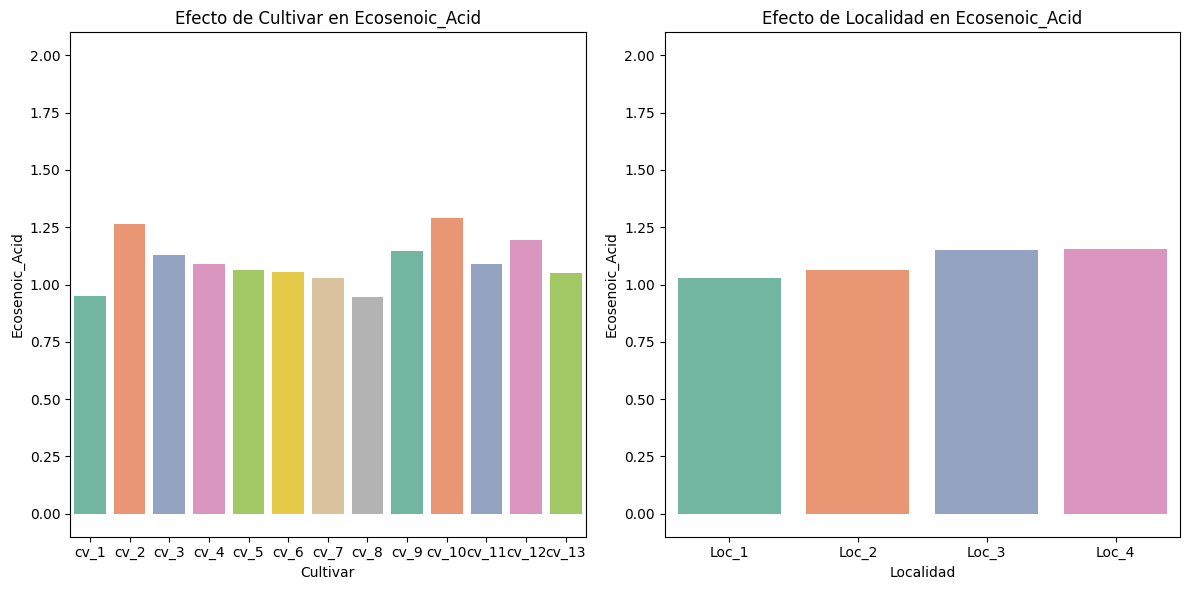

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

def analyze_factor_effect(anova_table, factor_name):
    p_factor = anova_table.loc[factor_name, 'PR(>F)']
    if p_factor < 0.05:
        return f"El factor '{factor_name}' tiene un efecto significativo en la variación."
    else:
        return f"El factor '{factor_name}' no tiene un efecto significativo en la variación."

def perform_anova(dataframe, response_column, factor_columns):
    df_prueba = dataframe.copy()
    df_prueba.columns = df_prueba.columns.str.replace(' ', '_')

    formula = f"{response_column} ~ {' + '.join(factor_columns)} + {' * '.join(factor_columns)}"
    model = ols(formula, data=df_prueba).fit()

    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA para la columna {response_column} : ","\n\n",anova_table,"\n")

    for factor in factor_columns:
        factor_effect = analyze_factor_effect(anova_table, factor)
        print(factor_effect)

    p_interaction = anova_table.loc['Cultivar:Localidad', 'PR(>F)']
    if p_interaction < 0.05:
        print("Hay una interacción significativa entre 'Cultivar' y 'Localidad'.")
    else:
        print("No hay una interacción significativa entre 'Cultivar' y 'Localidad'.")

    print("="*70)

def plot_factor_effects(dataframe, response_column, factor_columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 fila, 2 columnas

    ymin = dataframe[response_column].min() - 0.1
    ymax = dataframe[response_column].max() + 0.1

    for i, factor in enumerate(factor_columns):
        sns.barplot(x=factor, y=response_column, data=dataframe, ci=None, palette='Set2', ax=axes[i])
        axes[i].set_title(f'Efecto de {factor} en {response_column}')
        axes[i].set_xlabel(factor)
        axes[i].set_ylabel(response_column)
        axes[i].set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.show()

# Llama a la función para analizar ANOVA en todas las columnas de respuesta y genera gráficos
response_columns = ['Palmitic_Acid', 'Palmitoleic_Acid',
       'Stearic_Acid', 'Oleic_Acid', 'Linoleic_Acid', 'Linolenic_Acid',
       'Arachidic_Acid', 'Ecosenoic_Acid']
factor_columns = ['Cultivar', 'Localidad']

for col in response_columns:
    perform_anova(df_prueba, col, factor_columns)
    plot_factor_effects(df_prueba, col, factor_columns)


¿Existe interacción genotipo-ambiente?

¿Qué cultivar/es recomendaría en sentido amplio o sitio específico?